#### 농구선수의 게임 기록을 학습해서 포지션을 예측하기

In [1]:
import pandas as pd
import numpy as np
np.random.seed(5)

In [2]:
train = pd.read_csv("../Data/basketball_train.csv")
test = pd.read_csv("../Data/basketball_test.csv")

# 정규화를 해주자

# 정규화
# Player = train['Player']
# Pos = train['Pos']
# threeP = train['3P'] / train['3P'].max()
# trb = train['TRB'] / train['TRB'].max()
# blk = train['BLK'] / train['BLK'].max()

# train = pd.concat(
#   [Player, Pos, threeP, trb, blk],
#   axis=1
# )

# train.columns = ['Player', 'Pos', '3P', 'TRB', 'BLK']
# train.head()


train['3P'] = train['3P'] / train['3P'].max()
train['TRB'] = train['TRB'] / train['TRB'].max()
train['BLK'] = train['BLK'] / train['BLK'].max()


test['3P'] = test['3P'] / test['3P'].max()
test['TRB'] = test['TRB'] / test['TRB'].max()
test['BLK'] = test['BLK'] / test['BLK'].max()



In [ ]:
print(train.head())
print(test.head())


               Player Pos        3P       TRB       BLK
0         Danny Green  SG  0.500000  0.234043  0.266667
1          Al Horford   C  0.382353  0.482270  0.433333
2       Austin Rivers  SG  0.441176  0.156028  0.033333
3       Channing Frye   C  0.558824  0.276596  0.166667
4  Karl-Anthony Towns   C  0.352941  0.872340  0.433333
            Player Pos        3P       TRB       BLK
0     Steven Adams   C  0.000000  0.836957  0.769231
1  Jordan Crawford  SG  0.791667  0.195652  0.076923
2       Joe Harris  SG  0.666667  0.304348  0.153846
3      Gary Harris  SG  0.791667  0.336957  0.076923
4     Marcus Smart  SG  0.500000  0.423913  0.307692


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  80 non-null     object 
 1   Pos     80 non-null     object 
 2   3P      80 non-null     float64
 3   TRB     80 non-null     float64
 4   BLK     80 non-null     float64
dtypes: float64(3), object(2)
memory usage: 3.3+ KB


In [5]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  20 non-null     object 
 1   Pos     20 non-null     object 
 2   3P      20 non-null     float64
 3   TRB     20 non-null     float64
 4   BLK     20 non-null     float64
dtypes: float64(3), object(2)
memory usage: 932.0+ bytes


---
#### 최적의 k찾기 / 교차검증 (Cross Validation)

In [49]:
from sklearn.neighbors import KNeighborsClassifier

train.shape


(80, 5)

In [7]:
# 최적의 k를 찾기 위해 교차검증을 수행할 k의 범위를 3부터 학습데이터의 절반까지 지정
max_k_range = train.shape[0] // 2
max_k_range

40

In [8]:
k_list = [i for i in range(3, max_k_range, 2)]
k_list


[3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39]

In [9]:
list(range(3,max_k_range,2))

[3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39]

In [10]:
# Feature,  Target 나누기
X_train = train[['3P', 'BLK', 'TRB']]
y_train = train[['Pos']]

In [11]:
X_train.head()

,3P,BLK,TRB
0,0.500000,0.266667,0.234043
1,0.382353,0.433333,0.482270
2,0.441176,0.033333,0.156028
3,0.558824,0.166667,0.276596
4,0.352941,0.433333,0.872340


In [12]:
y_train.head()

,Pos
0,SG
1,C
2,SG
3,C
4,C


In [13]:
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

In [14]:
# 교차검증을 10 fold
cross_validation_scores = []

for k in k_list:
  knn = KNeighborsClassifier(n_neighbors=k)
  scores = cross_val_score(
    knn,
    X_train,
    y_train,
    cv=10, # 10번 나눌꺼야
    scoring='accuracy' # 정확도로 볼꺼야
  )
  cross_validation_scores.append(scores.mean())

cross_validation_scores

[0.9375,
 0.95,
 0.9625,
 0.9625,
 0.95,
 0.95,
 0.95,
 0.95,
 0.95,
 0.9375,
 0.9375,
 0.9375,
 0.9375,
 0.9375,
 0.9375,
 0.9375,
 0.9375,
 0.9375,
 0.9375]

In [15]:
len(cross_validation_scores)

19

In [16]:
import matplotlib.pyplot as plt

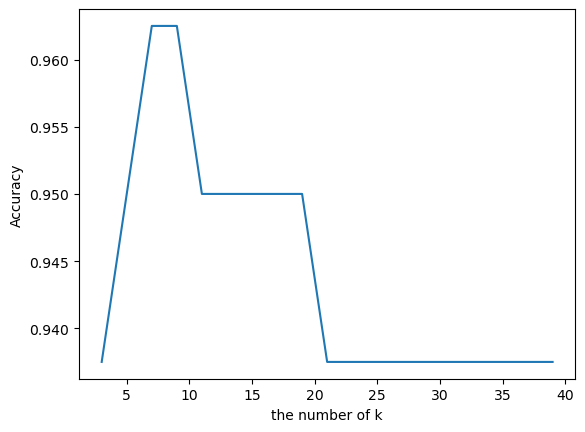

In [17]:
# k에 따른 정확도를 시각화
plt.plot(
  k_list,
  cross_validation_scores
)

plt.xlabel("the number of k")
plt.ylabel("Accuracy")

plt.show()

In [18]:
# 가장 예측율이 높은 k를 선정
k_list[cross_validation_scores.index(max(cross_validation_scores))]

7

---
### 2개의 특징으로 에측하기(3점슛, 블로킹)

In [19]:
knn = KNeighborsClassifier(n_neighbors=7)
X_train = train[['3P','BLK']]
y_train = train[['Pos']]
knn.fit(X_train,y_train)

X_test = test[['3P','BLK']]
y_test = test[['Pos']]

pred = knn.predict(X_test)
pred

array(['C', 'SG', 'SG', 'SG', 'C', 'C', 'C', 'C', 'C', 'SG', 'C', 'C',
       'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'C', 'SG'], dtype=object)

In [20]:
# 실제값과 예측값 비교
comparison = pd.DataFrame(
  {'예측값':pred, '정답':y_test.values.ravel()}  # 타입을 버리게 하는 ravel
)
comparison.head()

,예측값,정답
0,C,C
1,SG,SG
2,SG,SG
3,SG,SG
4,C,SG


In [21]:
y_test.values.ravel()

array(['C', 'SG', 'SG', 'SG', 'SG', 'C', 'C', 'SG', 'C', 'SG', 'C', 'C',
       'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'C', 'SG'], dtype=object)

In [22]:
knn.score(X_test, y_test)

0.9

### Confusion Matrix

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

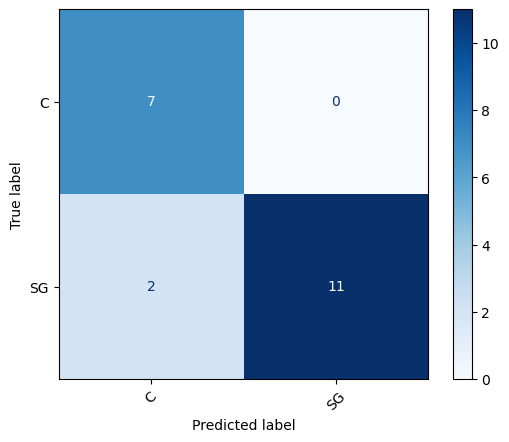

In [24]:
conf_matrix = confusion_matrix(y_test.values.ravel(), pred)
target_names = ['C','SG']
disp = ConfusionMatrixDisplay(
  confusion_matrix=conf_matrix,
  display_labels=target_names
)
disp.plot(
  cmap=plt.cm.Blues,
  xticks_rotation=45 
)
plt.show()

---

3P : 3.4


BLK : 0.5


TRB : 3.7

In [25]:
new = [[(3.4 / train['3P'].max()), (0.5 / train['BLK'].max())]]

knn.predict(new)

array(['SG'], dtype=object)

### 3개의 특징으로 예측하기

In [26]:
knn = KNeighborsClassifier(n_neighbors=7)
X_train = train[['3P','BLK','TRB']]
y_train = train[['Pos']]
knn.fit(X_train,y_train)

X_test = test[['3P','BLK','TRB']]
y_test = test[['Pos']]

pred = knn.predict(X_test)
pred

array(['C', 'SG', 'SG', 'SG', 'C', 'C', 'C', 'C', 'C', 'SG', 'C', 'C',
       'C', 'SG', 'SG', 'SG', 'SG', 'SG', 'C', 'SG'], dtype=object)

In [27]:
# 실제값과 예측값 비교
comparison = pd.DataFrame(
  {'예측값':pred, '정답':y_test.values.ravel()}  # 타입을 버리게 하는 ravel
)
comparison.head()

,예측값,정답
0,C,C
1,SG,SG
2,SG,SG
3,SG,SG
4,C,SG


In [28]:
y_test.values.ravel()

array(['C', 'SG', 'SG', 'SG', 'SG', 'C', 'C', 'SG', 'C', 'SG', 'C', 'C',
       'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'C', 'SG'], dtype=object)

In [29]:
knn.score(X_test, y_test)

0.85

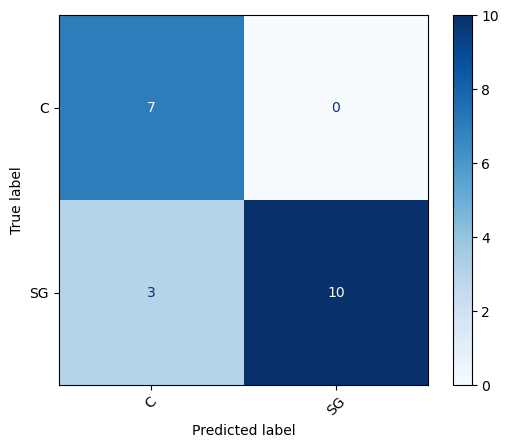

In [30]:
conf_matrix = confusion_matrix(y_test.values.ravel(), pred)
target_names = ['C','SG']
disp = ConfusionMatrixDisplay(
  confusion_matrix=conf_matrix,
  display_labels=target_names
)
disp.plot(
  cmap=plt.cm.Blues,
  xticks_rotation=45 
)
plt.show()

In [31]:
new = [[(3.4 / train['3P'].max()), (0.5 / train['BLK'].max()), (3.7 / train['TRB'].max())]]

knn.predict(new)

array(['SG'], dtype=object)

---
### iris를 가지고 Cross validation

In [32]:
iris = pd.read_csv("../Data/iris.csv")

In [33]:
iris['SepalLength'] = iris['SepalLength'] / iris['SepalLength'].max()
iris['SepalWidth'] = iris['SepalWidth'] / iris['SepalWidth'].max()
iris['PetalLength'] = iris['PetalLength'] / iris['PetalLength'].max()
iris['PetalWidth'] = iris['PetalWidth'] / iris['PetalWidth'].max()
iris.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Name
0,0.645570,0.795455,0.202899,0.08,Iris-setosa
1,0.620253,0.681818,0.202899,0.08,Iris-setosa
2,0.594937,0.727273,0.188406,0.08,Iris-setosa
3,0.582278,0.704545,0.217391,0.08,Iris-setosa
4,0.632911,0.818182,0.202899,0.08,Iris-setosa


In [55]:
from sklearn.model_selection import train_test_split
train, test = \
  train_test_split(
    iris,
    test_size=0.2
  )

In [56]:
# 최적의 k를 찾기 위해 교차검증을 수행할 k의 범위를 3부터 학습데이터의 절반까지 지정
max_k_range = train.shape[0] // 2
max_k_range

60

In [57]:
k_list = [i for i in range(3, max_k_range, 2)]
k_list

[3,
 5,
 7,
 9,
 11,
 13,
 15,
 17,
 19,
 21,
 23,
 25,
 27,
 29,
 31,
 33,
 35,
 37,
 39,
 41,
 43,
 45,
 47,
 49,
 51,
 53,
 55,
 57,
 59]

In [61]:
# Feature,  Target 나누기
X_train = train.iloc[:,:4]
y_train = train.loc[:,'Name']

In [62]:
X_train.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth
138,0.759494,0.681818,0.695652,0.72
33,0.696203,0.954545,0.202899,0.08
139,0.873418,0.704545,0.782609,0.84
111,0.810127,0.613636,0.768116,0.76
112,0.860759,0.681818,0.797101,0.84


In [63]:
y_train.head()

138    Iris-virginica
33        Iris-setosa
139    Iris-virginica
111    Iris-virginica
112    Iris-virginica
Name: Name, dtype: object

In [64]:
cross_validation_scores = []

for k in k_list:
  knn = KNeighborsClassifier(n_neighbors=k)
  scores = cross_val_score(
    knn,
    X_train,
    y_train,
    cv=10, # 10번 나눌꺼야
    scoring='accuracy' # 정확도로 볼꺼야
  )
  cross_validation_scores.append(scores.mean())

cross_validation_scores

[0.9583333333333333,
 0.9583333333333333,
 0.9583333333333333,
 0.9583333333333333,
 0.9583333333333333,
 0.9583333333333333,
 0.9583333333333333,
 0.9583333333333333,
 0.9583333333333333,
 0.95,
 0.95,
 0.95,
 0.95,
 0.95,
 0.95,
 0.9583333333333334,
 0.9583333333333334,
 0.9583333333333334,
 0.9583333333333334,
 0.9583333333333334,
 0.9583333333333334,
 0.9583333333333334,
 0.9583333333333334,
 0.9583333333333334,
 0.9583333333333334,
 0.9583333333333334,
 0.9333333333333333,
 0.9416666666666668,
 0.95]

In [66]:
len(cross_validation_scores)

29

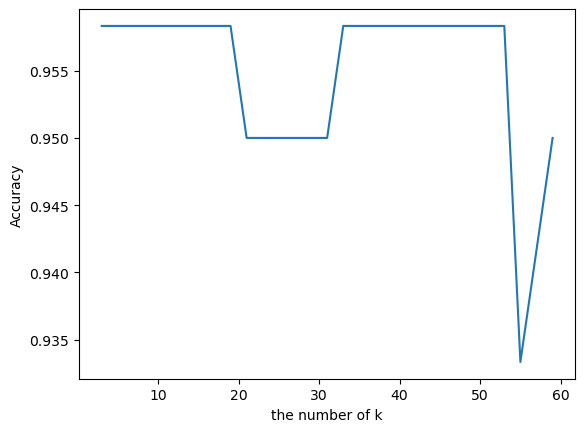

In [67]:
# k에 따른 정확도를 시각화
plt.plot(
  k_list,
  cross_validation_scores
)

plt.xlabel("the number of k")
plt.ylabel("Accuracy")

plt.show()

In [68]:
# 가장 예측율이 높은 k를 선정
k_list[cross_validation_scores.index(max(cross_validation_scores))]

33

In [69]:
knn = KNeighborsClassifier(n_neighbors=33)
X_train = train[['SepalLength','SepalWidth','PetalLength','PetalWidth']]
y_train = train[['Name']]
knn.fit(X_train,y_train)

X_test = test[['SepalLength','SepalWidth','PetalLength','PetalWidth']]
y_test = test[['Name']]

pred = knn.predict(X_test)
pred

array(['Iris-virginica', 'Iris-setosa', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-virginica', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-setosa', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-setosa', 'Iris-virginica', 'Iris-setosa',
       'Iris-versicolor', 'Iris-virginica', 'Iris-virginica',
       'Iris-setosa', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-virginica', 'Iris-versicolor', 'Iris-setosa',
       'Iris-versicolor', 'Iris-setosa', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-virginica', 'Iris-versicolor',
       'Iris-virginica', 'Iris-versicolor'], dtype=object)

In [70]:
# 실제값과 예측값 비교
comparison = pd.DataFrame(
  {'예측값':pred, '정답':y_test.values.ravel()}  # 타입을 버리게 하는 ravel
)
comparison.head()

,예측값,정답
0,Iris-virginica,Iris-virginica
1,Iris-setosa,Iris-setosa
2,Iris-versicolor,Iris-versicolor
3,Iris-versicolor,Iris-versicolor
4,Iris-virginica,Iris-virginica


In [71]:
y_test.values.ravel()

array(['Iris-virginica', 'Iris-setosa', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-virginica', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-setosa', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-setosa', 'Iris-virginica', 'Iris-setosa',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-virginica',
       'Iris-setosa', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-virginica', 'Iris-versicolor', 'Iris-setosa',
       'Iris-versicolor', 'Iris-setosa', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-virginica', 'Iris-versicolor',
       'Iris-virginica', 'Iris-versicolor'], dtype=object)

In [72]:
knn.score(X_test, y_test)

0.9666666666666667

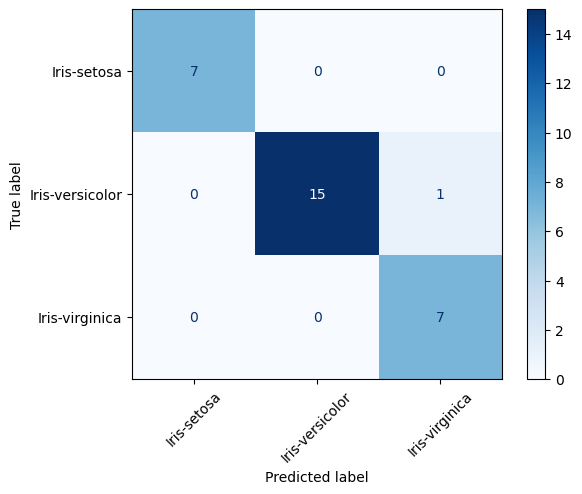

In [73]:
conf_matrix = confusion_matrix(y_test.values.ravel(), pred)
target_names = ['Iris-setosa','Iris-versicolor','Iris-virginica']
disp = ConfusionMatrixDisplay(
  confusion_matrix=conf_matrix,
  display_labels=target_names
)
disp.plot(
  cmap=plt.cm.Blues,
  xticks_rotation=45 
)
plt.show()